# Una cápsula que potabiliza agua solo agitándola

**De un millón de microbios a menos de uno.** Eso es lo que significa "6 logaritmos de remoción", y esta cápsula del tamaño de tu pulgar lo logra en 20 minutos —sin pilas y sin químicos—. La energía sale de agitarla.

La probaron en agua de grifo, de río y de lago, contra tres microbios de referencia: la bacteria *E. coli*, el virus MS2 y una espora de *B. subtilis* —el enemigo más duro de matar—. Aquí abrimos sus datos.

:::{image} figuras/pixabot.png
:alt: Mascota Pixabot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** [Self-powered floating capsule for decentralized water detection and disinfection](https://doi.org/10.1038/s44221-026-00655-4) · *Nature Water* (2026)
**DOI:** [10.1038/s44221-026-00655-4](https://doi.org/10.1038/s44221-026-00655-4)

[![Abrir en Colab]( https://colab.research.google.com/assets/colab-badge.svg )](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-08-capsula-flotante-agua/notebook.ipynb)

🎥 **Video:** [Ver en YouTube](https://youtube.com/shorts/vE4msi4HtP4)

## Dos trabajos en un solo aparato

Llevar agua segura a donde no hay red eléctrica ni laboratorio es un problema viejo. La idea del equipo fue meter dos funciones en una cápsula que flota:

1. **Medir.** Lee los sólidos disueltos totales (TDS) del agua —una pista rápida de cuánta porquería lleva disuelta— y transmite el número por Bluetooth.
2. **Desinfectar.** Si el TDS dice que el agua no está químicamente fuera de rango, la cápsula arranca sola: su carcasa genera cargas eléctricas que se concentran en la punta de unas nano-agujas, creando campos tan intensos que rompen la membrana de los microbios (*electroporación*).

Lo llamativo es de dónde sale la corriente: de agitar la cápsula a mano, por inducción electromagnética. Cero baterías, cero cloro. Veamos si los datos respaldan las dos promesas.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
SLUG = "2026-06-08-capsula-flotante-agua"
PATOGENO = 'E. coli'          # prueba: 'B. subtilis', 'MS2'
COLOR_ECOLI = '#2563EB'       # azul CaM — bacteria
COLOR_BSUB  = '#DC2626'       # rojo — la espora, el enemigo más duro
COLOR_MS2   = '#059669'       # emerald — virus
COLOR_PODER = '#7C3AED'       # violeta — potencia
COLOR_PICO  = '#DC2626'       # rojo — punto óptimo
LIMITE_DETECCION = 6.0        # log de remoción medibles: más arriba = sin microbios vivos
FUENTE = 'Fuente: Self-powered floating capsule (Nature Water, 2026) · DOI 10.1038/s44221-026-00655-4 | Datos: Source Data del paper'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

def num(v, dec=1):  # decimales con coma (español)
    return f"{v:.{dec}f}".replace('.', ',')

COLORES = {'E. coli': COLOR_ECOLI, 'B. subtilis': COLOR_BSUB, 'MS2': COLOR_MS2}

# Estilo CaM: local (repo) → /tmp (container) → GitHub raw (Colab)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

DATOS = 'datos'
def cargar(nombre):
    p = f'{DATOS}/{nombre}'
    if not os.path.exists(p):                      # Colab: descargar
        os.makedirs(DATOS, exist_ok=True)
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{nombre}', p)
    return pd.read_csv(p)

desinfeccion = cargar('desinfeccion_tiempo.csv')
sensor       = cargar('sensor_vs_comercial.csv')
potencia     = cargar('potencia_vs_carga.csv')
durabilidad  = cargar('durabilidad_ciclos.csv')

print('Microbios probados:', ', '.join(desinfeccion['patogeno'].unique()))
print('Aguas reales probadas:', ', '.join(a.replace(' Water','') for a in sensor['muestra_agua'].unique()))
print(f'Ciclos de durabilidad: {int(durabilidad["ciclo"].max())}')
pico = potencia.loc[potencia['densidad_potencia_mw_cm3'].idxmax()]
print(f'Potencia pico: {num(pico["densidad_potencia_mw_cm3"],2)} mW/cm³ a {int(pico["impedancia_ohm"])} Ω')

Microbios probados: E. coli, B. subtilis, MS2
Aguas reales probadas: Tap, River, Lake
Ciclos de durabilidad: 120
Potencia pico: 2,07 mW/cm³ a 3000 Ω


## Aquí está la curva de muerte.

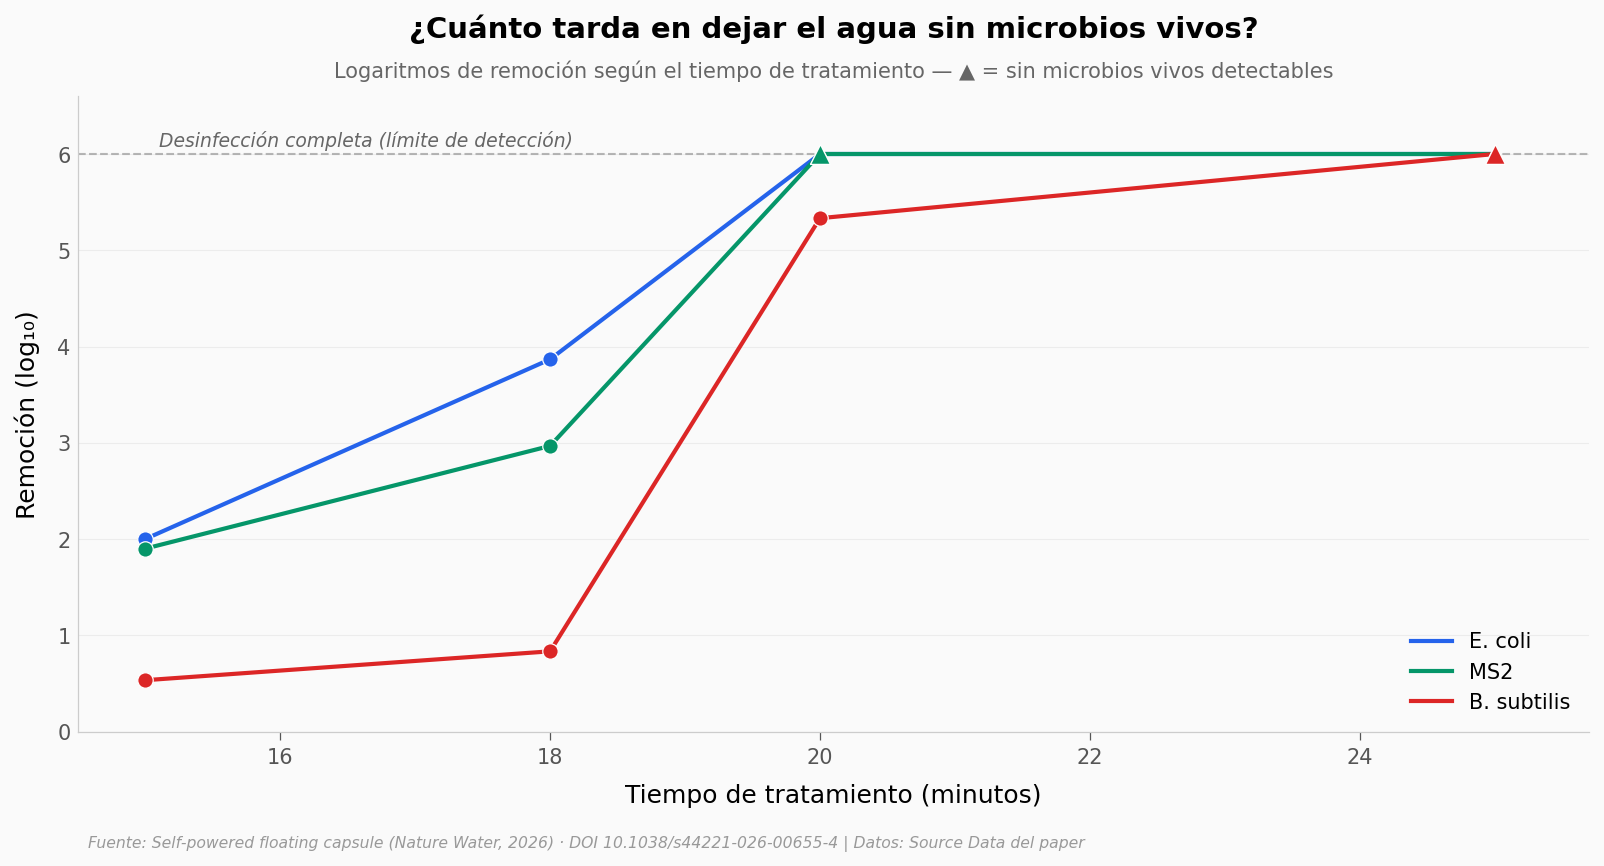

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

for pat in ['E. coli', 'MS2', 'B. subtilis']:
    d = desinfeccion[desinfeccion['patogeno'] == pat].sort_values('tiempo_min')
    color = COLORES[pat]
    # Línea + puntos medidos (label para la leyenda — las 3 curvas convergen
    # al final, así que la etiqueta inline se solaparía: usamos leyenda)
    ax.plot(d['tiempo_min'], d['log_removal_promedio'], '-', color=color, lw=2,
            zorder=4, label=pat)
    libres = d[~d['censurado_limite_deteccion']]
    cens   = d[d['censurado_limite_deteccion']]
    ax.scatter(libres['tiempo_min'], libres['log_removal_promedio'], color=color, s=55,
               edgecolors='white', linewidths=0.6, zorder=5)
    # Puntos censurados: triángulo hacia arriba = "≥ límite, sin microbios vivos"
    ax.scatter(cens['tiempo_min'], cens['log_removal_promedio'], color=color, s=90,
               marker='^', edgecolors='white', linewidths=0.6, zorder=6)

# Banda de desinfección completa
ax.axhline(LIMITE_DETECCION, color='#999999', lw=1, linestyle='--', alpha=0.7)
ax.text(15.1, LIMITE_DETECCION + 0.08, 'Desinfección completa (límite de detección)',
        fontsize=9, color='#666666', style='italic')

ax.set_title('¿Cuánto tarda en dejar el agua sin microbios vivos?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Logaritmos de remoción según el tiempo de tratamiento — ▲ = sin microbios vivos detectables',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Tiempo de tratamiento (minutos)')
ax.set_ylabel('Remoción (log₁₀)')
ax.set_xlim(14.5, 25.7)
ax.set_ylim(0, 6.6)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/curva_desinfeccion.png', dpi=200, bbox_inches='tight')
plt.show()

Tres curvas, tres velocidades. A los 15 minutos *E. coli* ya cayó 2 logaritmos y el virus MS2 casi otro tanto, pero la espora de *B. subtilis* apenas se inmutó: medio logaritmo. Las esporas tienen una cubierta blindada, y se nota.

A los 20 minutos *E. coli* y MS2 ya tocan el techo —sin microbios vivos que detectar—. La espora necesita cinco minutos más: solo a los 25 alcanza el mismo punto. La lección práctica es directa: **el tiempo de tratamiento lo manda el microbio más resistente.** Si quieres cubrir esporas, 25 minutos; no 20.

## Pero antes de desinfectar, decide

La cápsula no desinfecta a ciegas: primero mide el agua. Y ese sensor también se alimenta solo, agitándola. La pregunta obvia: ¿un sensor sin pilas le puede competir a uno comercial de verdad?

El equipo lo enfrentó cara a cara contra un medidor HANNA en las tres aguas.

Shapiro p: FDGD=0.012, HANNA=0.008 → Spearman ρ
Spearman ρ = 0.9068 (p = 7.4e-04) | MAE = 2,33 mg/L | MAPE = 1,26 %


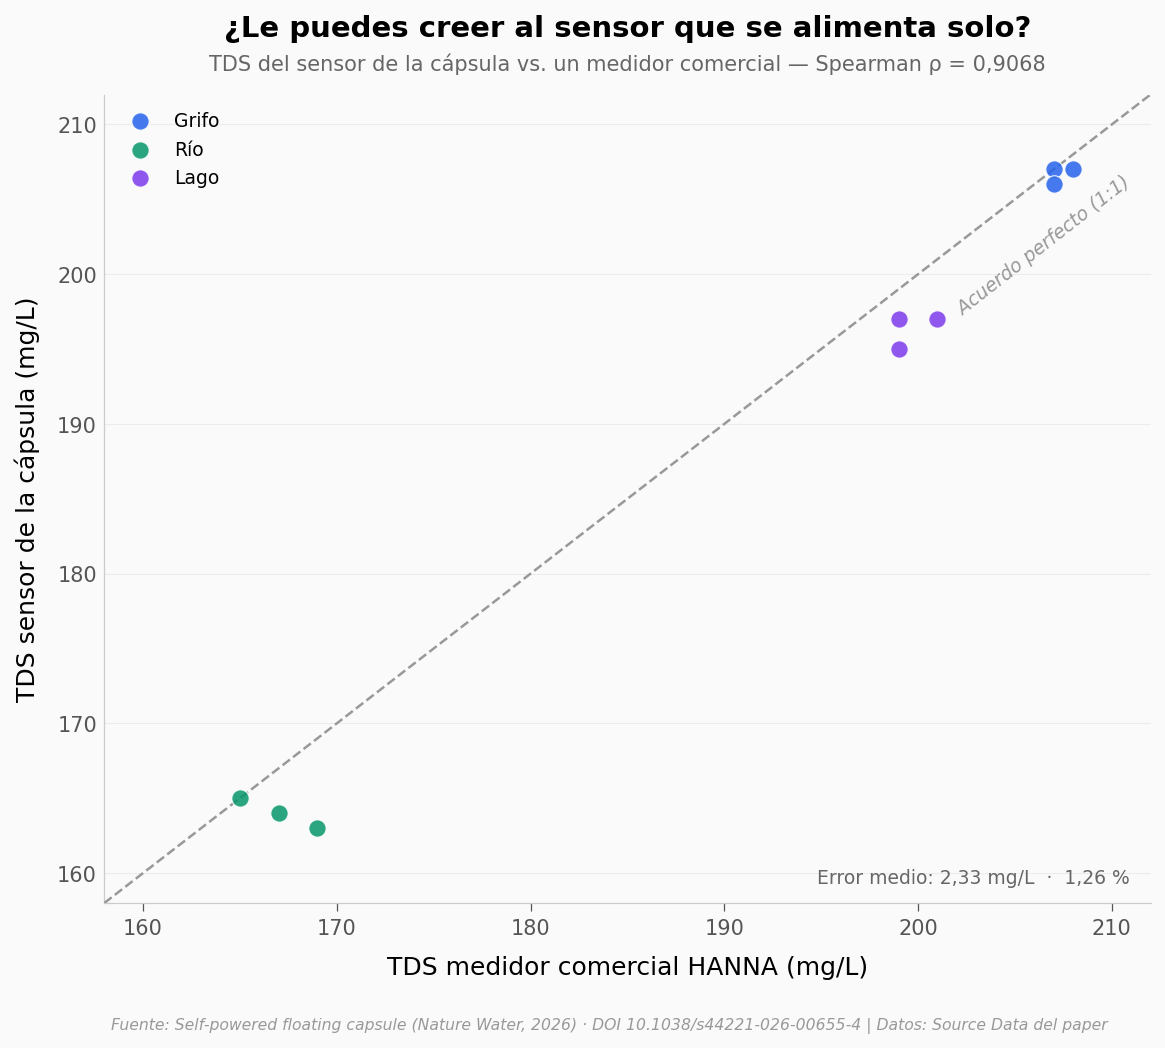

In [3]:
fdgd  = sensor['tds_fdgd_mg_l'].values
hanna = sensor['tds_hanna_mg_l'].values

# Métricas de acuerdo (lo que más importa en un sensor)
mae  = np.mean(np.abs(fdgd - hanna))
mape = np.mean(np.abs(fdgd - hanna) / hanna) * 100

# Correlación: testear normalidad antes de elegir Pearson vs Spearman (regla 33)
p_fdgd  = stats.shapiro(fdgd).pvalue
p_hanna = stats.shapiro(hanna).pvalue
if p_fdgd > 0.05 and p_hanna > 0.05:
    r, p = stats.pearsonr(fdgd, hanna);  nombre_r = 'Pearson r'
else:
    r, p = stats.spearmanr(fdgd, hanna); nombre_r = 'Spearman ρ'
print(f'Shapiro p: FDGD={p_fdgd:.3f}, HANNA={p_hanna:.3f} → {nombre_r}')
print(f'{nombre_r} = {r:.4f} (p = {p:.1e}) | MAE = {num(mae,2)} mg/L | MAPE = {num(mape,2)} %')

fig, ax = plt.subplots(figsize=(9, 7))
paleta = {'Tap Water': '#2563EB', 'River Water': '#059669', 'Lake Water': '#7C3AED'}
nombres = {'Tap Water': 'Grifo', 'River Water': 'Río', 'Lake Water': 'Lago'}
for agua, color in paleta.items():
    m = sensor['muestra_agua'] == agua
    ax.scatter(sensor.loc[m, 'tds_hanna_mg_l'], sensor.loc[m, 'tds_fdgd_mg_l'],
               color=color, s=70, alpha=0.85, edgecolors='white', linewidths=0.6,
               zorder=5, label=nombres[agua])

# Línea de acuerdo perfecto (1:1)
lo, hi = 158, 212
ax.plot([lo, hi], [lo, hi], '--', color='#999999', lw=1.2, zorder=3)
ax.text(hi - 1, hi - 6, 'Acuerdo perfecto (1:1)', color='#999999', fontsize=9,
        style='italic', ha='right', rotation=38, rotation_mode='anchor')

ax.set_title('¿Le puedes creer al sensor que se alimenta solo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'TDS del sensor de la cápsula vs. un medidor comercial — {nombre_r} = {num(r,4)}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('TDS medidor comercial HANNA (mg/L)')
ax.set_ylabel('TDS sensor de la cápsula (mg/L)')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.text(0.98, 0.02, f'Error medio: {num(mae,2)} mg/L  ·  {num(mape,2)} %',
        transform=ax.transAxes, fontsize=9, color='#666666', ha='right', va='bottom')

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sensor_vs_comercial.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿De dónde sale la corriente?

De agitarla. El movimiento mueve un imán dentro de una bobina y genera electricidad por inducción —el mismo principio de una linterna de sacudir—. Pero hay un detalle físico: cuánta potencia entrega depende de la resistencia del circuito que la recibe. Existe un punto dulce.

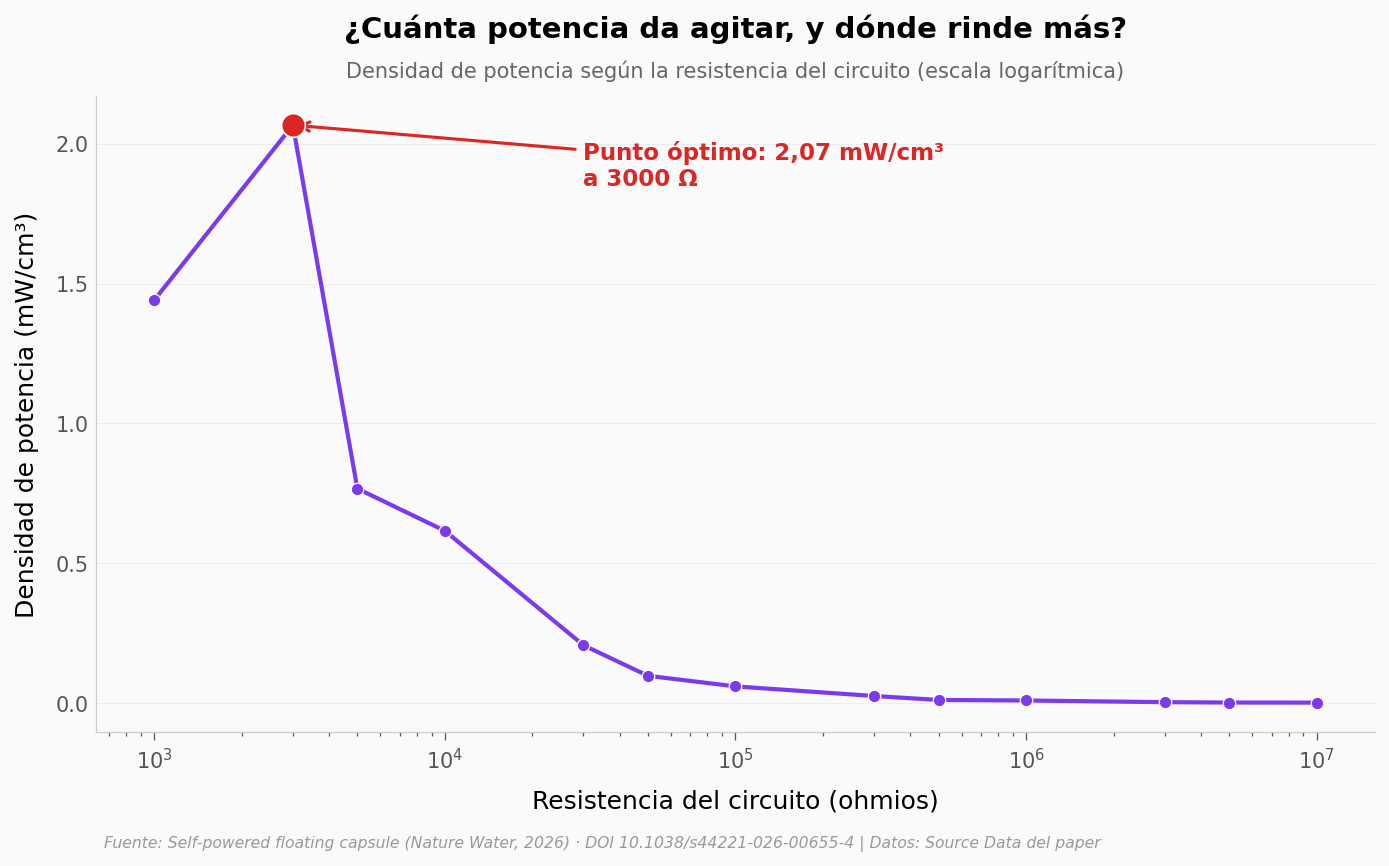

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(potencia['impedancia_ohm'], potencia['densidad_potencia_mw_cm3'],
        '-o', color=COLOR_PODER, lw=2, markersize=6, markeredgecolor='white',
        markeredgewidth=0.6, zorder=5)
ax.set_xscale('log')

# Marcar el pico de potencia
pico = potencia.loc[potencia['densidad_potencia_mw_cm3'].idxmax()]
ax.scatter([pico['impedancia_ohm']], [pico['densidad_potencia_mw_cm3']],
           color=COLOR_PICO, s=130, zorder=6, edgecolors='white', linewidths=0.8)
ax.annotate(f'Punto óptimo: {num(pico["densidad_potencia_mw_cm3"],2)} mW/cm³\na {int(pico["impedancia_ohm"])} Ω',
            xy=(pico['impedancia_ohm'], pico['densidad_potencia_mw_cm3']),
            xytext=(30000, 1.85), fontsize=11, fontweight='bold', color=COLOR_PICO,
            arrowprops=dict(arrowstyle='->', color=COLOR_PICO, lw=1.5))

ax.set_title('¿Cuánta potencia da agitar, y dónde rinde más?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Densidad de potencia según la resistencia del circuito (escala logarítmica)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Resistencia del circuito (ohmios)')
ax.set_ylabel('Densidad de potencia (mW/cm³)')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/potencia_carga.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y se gasta con el uso?

Un dispositivo que funciona una vez no sirve de nada. La prueba de fuego: repetir la desinfección 120 veces seguidas y ver si pierde fuelle.

E. coli: log sostenido = 5,95 a lo largo de 120 ciclos · desviación = 0,0000
B. subtilis: log sostenido = 5,48 a lo largo de 120 ciclos · desviación = 0,0000
MS2: log sostenido = 4,95 a lo largo de 120 ciclos · desviación = 0,0000


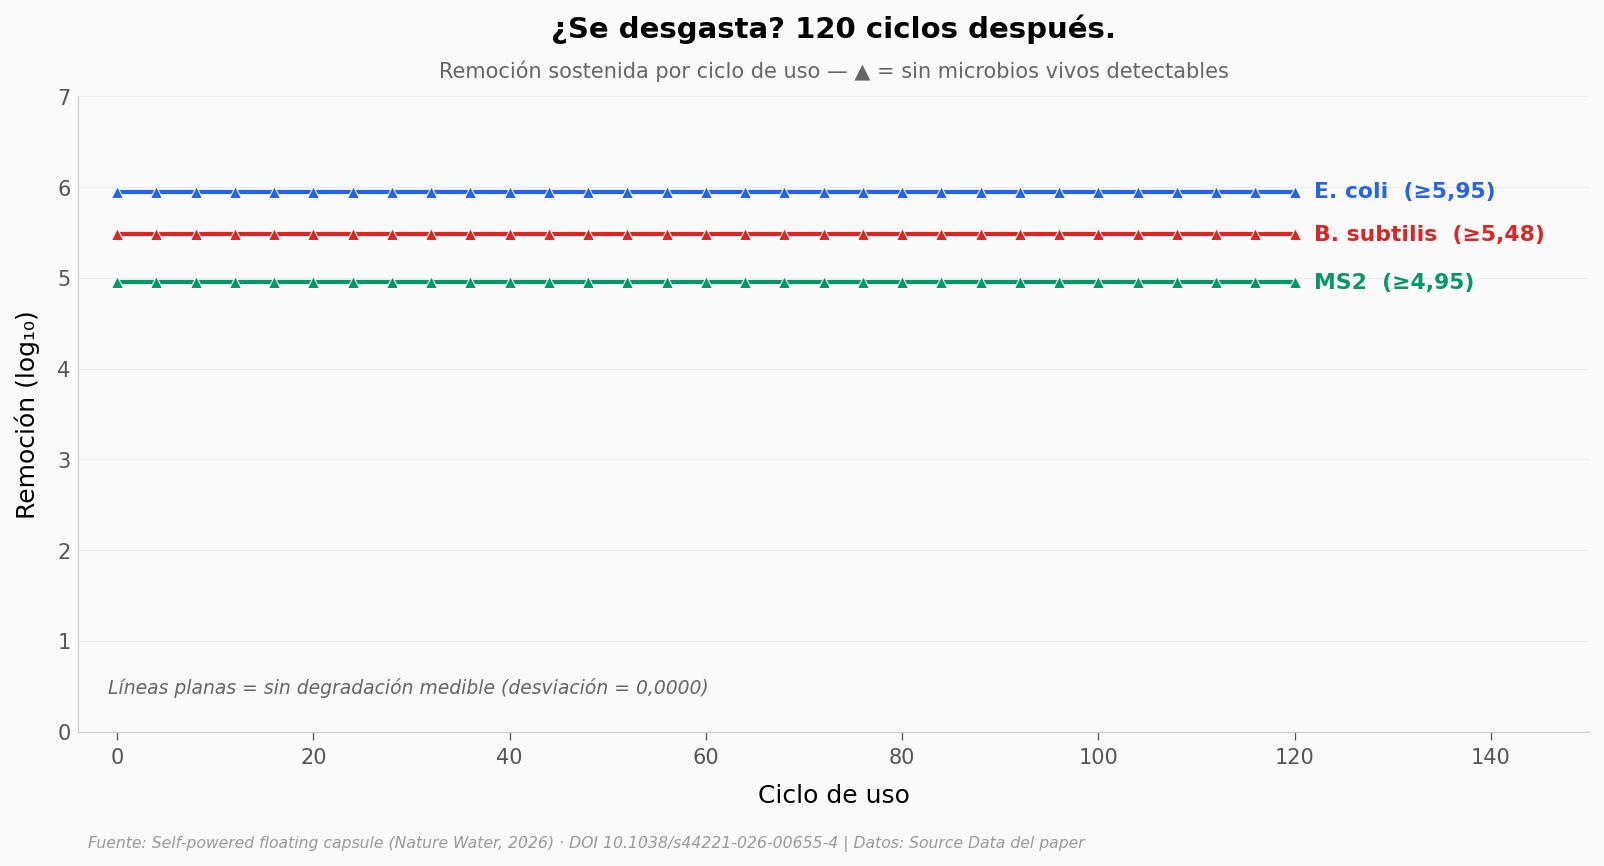

In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))

series = [('ecoli_log', 'E. coli', COLOR_ECOLI),
          ('bsubtilis_log', 'B. subtilis', COLOR_BSUB),
          ('ms2_log', 'MS2', COLOR_MS2)]
for col, nombre, color in series:
    ax.plot(durabilidad['ciclo'], durabilidad[col], '-^', color=color, lw=2,
            markersize=6, markeredgecolor='white', markeredgewidth=0.5, zorder=5)
    y = durabilidad[col].iloc[-1]
    ax.text(122, y, f'{nombre}  (≥{num(y,2)})', color=color, fontsize=10.5,
            fontweight='bold', va='center')
    desv = durabilidad[col].std(ddof=1)
    print(f'{nombre}: log sostenido = {num(y,2)} a lo largo de 120 ciclos · desviación = {num(desv,4)}')

ax.set_title('¿Se desgasta? 120 ciclos después.',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Remoción sostenida por ciclo de uso — ▲ = sin microbios vivos detectables',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Ciclo de uso')
ax.set_ylabel('Remoción (log₁₀)')
ax.set_xlim(-4, 150)
ax.set_ylim(0, 7)
ax.text(0.02, 0.06, 'Líneas planas = sin degradación medible (desviación = 0,0000)',
        transform=ax.transAxes, fontsize=9, color='#666666', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/durabilidad_ciclos.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La cápsula logra desinfección completa (6 log) | ✅ | A los 20 min para *E. coli* y MS2, a los 25 min para la espora *B. subtilis*. Los "6 log" son el **límite de detección**: significa sin microbios vivos detectables, no un conteo exacto. |
| La espora es el microbio más resistente | ✅ | A 15 min: *B. subtilis* 0,53 log vs *E. coli* 2,0 y MS2 1,9. Necesita 25 min para llegar al techo (los otros, 20). n = 3 réplicas por punto. |
| El sensor autoalimentado acierta como uno comercial | ✅ | Error medio de 2,33 mg/L (1,26 %) frente al medidor HANNA. Peor caso entre 9 pares: 6 mg/L (agua de río). Los datos no pasan el test de normalidad (Shapiro-Wilk p < 0,05), así que usamos correlación de rango en vez de Pearson: ρ = 0,91 (p < 0,001, n = 9). |
| El movimiento entrega potencia útil | ✅ | Pico de 2,07 mW/cm³ con la resistencia óptima (~3.000 Ω). Cae fuera de ese punto. |
| No se degrada con el uso | ✅ | Remoción constante a lo largo de 120 ciclos (desviación 0,0000); cada microbio sostiene su propio límite de detección (≥5,95 / ≥5,48 / ≥4,95 log). Todos los valores son **límites inferiores** (≥): sostiene desinfección completa, sin caída medible. |

> **Limitaciones:** todo es laboratorio con microbios de referencia y aguas recolectadas, no despliegue real en campo. Los valores "≥6 log" están censurados al límite de detección: no podemos afirmar *cuánto* más allá de 6 log mata. El sensor mide TDS, que es un *sustituto* de contaminación química —no detecta todos los contaminantes específicos—. La durabilidad se probó a 120 ciclos; más allá, desconocido.

## Ahora tú

1. **¿Cuánto tarda tu microbio?** Cambia `PATOGENO` en la configuración y mira en `desinfeccion` cuándo cruza a desinfección completa. ¿Cuál es el más lento?
   ```python
   desinfeccion[desinfeccion['patogeno'] == PATOGENO]
   ```

2. **¿Dónde falla más el sensor?** Calcula el error del sensor agua por agua. ¿En cuál se aleja más del comercial?
   ```python
   sensor.assign(error=(sensor['tds_fdgd_mg_l'] - sensor['tds_hanna_mg_l']).abs()) \
         .groupby('muestra_agua')['error'].mean()
   ```

3. **¿Cuánta potencia pierdes fuera del punto óptimo?** Divide la potencia pico entre la de 1 MΩ. ¿Cuántas veces menos rinde?
   ```python
   potencia['densidad_potencia_mw_cm3'].max() / \
       potencia.loc[potencia['impedancia_ohm'] == 1000000, 'densidad_potencia_mw_cm3'].values[0]
   ```

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto avanza la desinfección entre los 15 y los 18 minutos para cada microbio?
inicio = desinfeccion[desinfeccion['tiempo_min'] == 15].set_index('patogeno')['log_removal_promedio']
luego  = desinfeccion[desinfeccion['tiempo_min'] == 18].set_index('patogeno')['log_removal_promedio']
avance = (luego - inicio).sort_values(ascending=False)
for pat, delta in avance.items():
    print(f'{pat:14s}: +{num(delta,2)} log entre el minuto 15 y el 18')

E. coli       : +1,87 log entre el minuto 15 y el 18
MS2           : +1,07 log entre el minuto 15 y el 18
B. subtilis   : +0,30 log entre el minuto 15 y el 18


## Fuentes

**Paper**: [Self-powered floating capsule for decentralized water detection and disinfection](https://doi.org/10.1038/s44221-026-00655-4)  
*Nature Water, 2026-06-08*

**Source Data**: [Source Data (figuras 2–4, MOESM5–9 — mismo DOI)](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00655-4/MediaObjects/44221_2026_655_MOESM7_ESM.xlsx)

*14 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [repositorio del Lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-06-08-capsula-flotante-agua). Licencia de datos según la fuente original.*